# Logistic Regression Baseline for NBA Shot Success

This notebook builds a first-pass logistic regression baseline on the Kaggle 2014-15 NBA shot log dataset. The goal is to create a simple, reproducible shot-success model that the team can cite in the Week 3 Methodology writeup.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)


In [2]:
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]
relative_data_path = Path('data/raw/kaggle/shot_logs_2014_15/shot_logs.csv')

data_path = None
for root in candidate_roots:
    candidate = (root / relative_data_path).resolve()
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError(f'Missing dataset at {relative_data_path} from candidates: {candidate_roots}')

df = pd.read_csv(data_path)
print(f'Dataset path: {data_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Dataset path: /Users/marcrajesh/Documents/Capstone/data/raw/kaggle/shot_logs_2014_15/shot_logs.csv
Shape: 128,069 rows x 21 columns


,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,2,1.9,7.7,2,made,"Anderson, Alan",101187,1.3,1,2,brian roberts,203148
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0,0.8,28.2,3,missed,"Bogdanovic, Bojan",202711,6.1,0,0,brian roberts,203148
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,3,2.7,10.1,2,missed,"Bogdanovic, Bojan",202711,0.9,0,0,brian roberts,203148
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,2,1.9,17.2,2,missed,"Brown, Markel",203900,3.4,0,0,brian roberts,203148
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2,2.7,3.7,2,missed,"Young, Thaddeus",201152,1.1,0,0,brian roberts,203148


In [3]:
target_counts = df['SHOT_RESULT'].value_counts().rename_axis('SHOT_RESULT').reset_index(name='count')
target_counts['share'] = target_counts['count'] / len(df)
target_counts


,SHOT_RESULT,count,share
0,missed,70164,0.547861
1,made,57905,0.452139


In [4]:
def clock_to_seconds(value: str) -> float:
    if pd.isna(value):
        return np.nan
    minutes, seconds = str(value).split(':')
    return int(minutes) * 60 + int(seconds)

model_df = df.copy()
model_df['GAME_CLOCK_SECONDS'] = model_df['GAME_CLOCK'].map(clock_to_seconds)
model_df['SHOT_MADE'] = (model_df['SHOT_RESULT'] == 'made').astype(int)

used_columns = [
    'LOCATION',
    'W',
    'FINAL_MARGIN',
    'SHOT_NUMBER',
    'PERIOD',
    'SHOT_CLOCK',
    'DRIBBLES',
    'TOUCH_TIME',
    'SHOT_DIST',
    'PTS_TYPE',
    'CLOSE_DEF_DIST',
    'GAME_CLOCK_SECONDS',
]

excluded_columns = [
    'GAME_ID',           # identifier only
    'MATCHUP',           # text-heavy game descriptor, not needed for baseline
    'GAME_CLOCK',        # replaced with GAME_CLOCK_SECONDS
    'SHOT_RESULT',       # target
    'FGM',               # direct duplicate of target outcome
    'PTS',               # realized points, leaks the outcome
    'CLOSEST_DEFENDER',  # high-cardinality identity field
    'CLOSEST_DEFENDER_PLAYER_ID',
    'player_name',
    'player_id',
]

X = model_df[used_columns]
y = model_df['SHOT_MADE']

print('Features used:')
print(used_columns)
print() 
print('Excluded columns:')
print(excluded_columns)
X.head()


Features used:
['LOCATION', 'W', 'FINAL_MARGIN', 'SHOT_NUMBER', 'PERIOD', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'SHOT_DIST', 'PTS_TYPE', 'CLOSE_DEF_DIST', 'GAME_CLOCK_SECONDS']

Excluded columns:
['GAME_ID', 'MATCHUP', 'GAME_CLOCK', 'SHOT_RESULT', 'FGM', 'PTS', 'CLOSEST_DEFENDER', 'CLOSEST_DEFENDER_PLAYER_ID', 'player_name', 'player_id']


,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,SHOT_DIST,PTS_TYPE,CLOSE_DEF_DIST,GAME_CLOCK_SECONDS
0,A,W,24,1,1,10.8,2,1.9,7.7,2,1.3,69
1,A,W,24,2,1,3.4,0,0.8,28.2,3,6.1,14
2,A,W,24,3,1,NaN,3,2.7,10.1,2,0.9,0
3,A,W,24,4,2,10.3,2,1.9,17.2,2,3.4,707
4,A,W,24,5,2,10.9,2,2.7,3.7,2,1.1,634


In [5]:
numeric_features = [
    'FINAL_MARGIN',
    'SHOT_NUMBER',
    'PERIOD',
    'SHOT_CLOCK',
    'DRIBBLES',
    'TOUCH_TIME',
    'SHOT_DIST',
    'CLOSE_DEF_DIST',
    'GAME_CLOCK_SECONDS',
]

categorical_features = ['LOCATION', 'W', 'PTS_TYPE']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs')),
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (102455, 12)
Test shape: (25614, 12)


In [6]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {accuracy:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred, digits=4))


Accuracy: 0.6074
ROC-AUC: 0.6321

Classification report:
              precision    recall  f1-score   support

           0     0.6206    0.7295    0.6706     14033
           1     0.5837    0.4595    0.5142     11581

    accuracy                         0.6074     25614
   macro avg     0.6021    0.5945    0.5924     25614
weighted avg     0.6039    0.6074    0.5999     25614



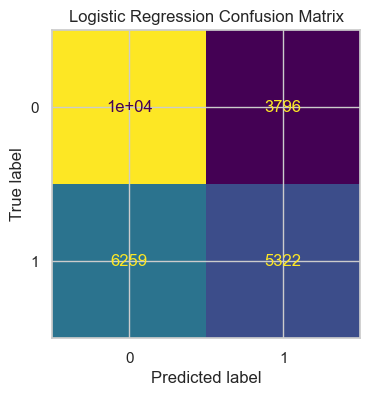

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title('Logistic Regression Confusion Matrix')
plt.show()


In [8]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df = coef_df.sort_values('coefficient', ascending=False).reset_index(drop=True)

print('Top positive coefficients (increase predicted make probability):')
display(coef_df.head(10))

print('Top negative coefficients (decrease predicted make probability):')
display(coef_df.tail(10).sort_values('coefficient'))


Top positive coefficients (increase predicted make probability):


,feature,coefficient
0,num__CLOSE_DEF_DIST,0.280407
1,num__FINAL_MARGIN,0.107367
2,num__SHOT_CLOCK,0.084240
3,num__DRIBBLES,0.083681
4,num__SHOT_NUMBER,0.031861
5,num__GAME_CLOCK_SECONDS,0.008674
6,cat__PTS_TYPE_3,0.005309
7,cat__W_W,-0.018034
8,num__PERIOD,-0.023778
9,cat__LOCATION_A,-0.032659


Top negative coefficients (decrease predicted make probability):


,feature,coefficient
14,num__SHOT_DIST,-0.573156
13,num__TOUCH_TIME,-0.160416
12,cat__PTS_TYPE_2,-0.078285
11,cat__W_L,-0.054943
10,cat__LOCATION_H,-0.040317
9,cat__LOCATION_A,-0.032659
8,num__PERIOD,-0.023778
7,cat__W_W,-0.018034
6,cat__PTS_TYPE_3,0.005309
5,num__GAME_CLOCK_SECONDS,0.008674


In [9]:
summary = pd.DataFrame({
    'metric': ['accuracy', 'roc_auc', 'train_rows', 'test_rows', 'features_used'],
    'value': [
        round(accuracy, 4),
        round(roc_auc, 4),
        len(X_train),
        len(X_test),
        len(feature_names),
    ],
})
summary


,metric,value
0,accuracy,0.6074
1,roc_auc,0.6321
2,train_rows,102455.0000
3,test_rows,25614.0000
4,features_used,15.0000


## Interpretation

- This baseline is intentionally simple: it models make/miss using shot context features and a small set of game-state variables.
- It should do a decent job capturing broad shot-quality patterns like distance, shot clock, touch time, and defender proximity.
- It does **not** yet include richer player identity effects, lineup context, tracking-era features, or nonlinear interactions.
- A stronger next model would likely improve performance by using tree-based methods, better feature engineering, and eventually the full enriched table built from the project pipeline.
